In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv('civil_construction_project_delay_dataset.csv')
df.info()
print("\n--- Summary Statistics ---")
print(df.describe())

print("\n--- Target Variable ('ProjectDelayed') Distribution ---")
print(df['ProjectDelayed'].value_counts())

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

df.drop_duplicates(inplace=True)

#Fix project type to proper consistent case
if 'ProjectType' in df.columns:
    df['ProjectType'] = df['ProjectType'].str.title()

#Cap outliers
cols_to_check = ['ProjectBudgetMillion', 'EstimatedDurationDays', 'WorkersAssigned', 
                 'EquipmentUtilization', 'CostOverrunPercent', 'ScheduleVarianceDays']
for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap values instead of dropping rows to preserve dataset size
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])


categorical_features = ['ProjectType', 'ProjectLocation', 'ContractorCategory', 'ConstructionPhase']
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

features_to_scale = df.select_dtypes(include=['float64', 'int64']).columns
features_to_scale = features_to_scale.drop('ProjectDelayed', errors='ignore')

scaler = StandardScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("\n--- Data Preprocessing and Scaling Complete ---")
print(df.head())

le = LabelEncoder()

df['ProjectDelayed'] = le.fit_transform(df['ProjectDelayed'])
df.drop('ProjectID', axis=1, inplace=True)

# features_to_scale = features_to_scale.drop('ProjectDelayed', errors='ignore')

# scaler = StandardScaler()
# df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("\n--- Data Preprocessing and Scaling Complete ---")
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32250 entries, 0 to 32249
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ProjectID              32250 non-null  object 
 1   ProjectType            32250 non-null  object 
 2   ProjectLocation        32250 non-null  object 
 3   ContractorCategory     32250 non-null  object 
 4   ConstructionPhase      32250 non-null  object 
 5   ProjectBudgetMillion   31281 non-null  float64
 6   EstimatedDurationDays  32250 non-null  int64  
 7   WorkersAssigned        32250 non-null  int64  
 8   EquipmentUtilization   31285 non-null  float64
 9   MaterialDelayDays      32250 non-null  int64  
 10  SupplierIssues         32250 non-null  int64  
 11  WeatherDisruptionDays  32250 non-null  int64  
 12  SafetyIncidents        32250 non-null  int64  
 13  InspectionFailures     32250 non-null  int64  
 14  ChangeRequests         32250 non-null  int64  
 15  Co

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectFromModel


from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

X = df.drop('ProjectDelayed', axis=1)
y = df['ProjectDelayed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize and fit the Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# 3. View individual importance metrics (Optional)
importances = dt_model.feature_importances_
for feature, importance in zip(X.columns, importances):
    print(f"Feature: {feature:20} Importance: {importance:.4f}")

# 4. Use SelectFromModel to automatically select the best features
# The 'threshold' can be a specific number or heuristics like 'mean' or 'median'
selector = SelectFromModel(estimator=dt_model, threshold="mean", prefit=True)

# 5. Transform the dataset to retain only selected features
X_train_selected = selector.transform(X_train.values)
X_test_selected = selector.transform(X_test.values)

# Get the names of the columns that were kept
selected_features = X.columns[selector.get_support()]
print("\nSelected Features:", list(selected_features))



Feature: ProjectBudgetMillion Importance: 0.0000
Feature: EstimatedDurationDays Importance: 0.0023
Feature: WorkersAssigned      Importance: 0.0108
Feature: EquipmentUtilization Importance: 0.0037
Feature: MaterialDelayDays    Importance: 0.1669
Feature: SupplierIssues       Importance: 0.0629
Feature: WeatherDisruptionDays Importance: 0.0477
Feature: SafetyIncidents      Importance: 0.3232
Feature: InspectionFailures   Importance: 0.2671
Feature: ChangeRequests       Importance: 0.1020
Feature: CostOverrunPercent   Importance: 0.0000
Feature: ScheduleVarianceDays Importance: 0.0000
Feature: QualityScore         Importance: 0.0134
Feature: SiteProductivityScore Importance: 0.0000
Feature: ProjectType_Commercial Importance: 0.0000
Feature: ProjectType_Industrial Importance: 0.0000
Feature: ProjectType_Infrastructure Importance: 0.0000
Feature: ProjectType_Residential Importance: 0.0000
Feature: ProjectType_Road Construction Importance: 0.0000
Feature: ProjectLocation_Semi-Urban Importan

In [3]:
print(f"\nTraining data shape: {X_train_selected.shape}")
print(f"Testing data shape: {X_test_selected.shape}")

print("\n--- K-Nearest Neighbors (KNN) ---")
# Finding projects with similar operational characteristics to predict delay risk
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_selected, y_train)
knn_pred = knn.predict(X_test_selected)
print(f"KNN Accuracy: {accuracy_score(y_test, knn_pred):.4f}")

print("\n--- Ensemble Models ---")
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_selected, y_train)
rf_pred = rf_clf.predict(X_test_selected)
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.4f}")

# B. Train AdaBoost
# Sequentially focuses on projects that are difficult to classify correctly
ada_clf = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_clf.fit(X_train_selected, y_train)
ada_pred = ada_clf.predict(X_test_selected)
print(f"AdaBoost Accuracy: {accuracy_score(y_test, ada_pred):.4f}")

gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_clf.fit(X_train_selected, y_train)
gb_pred = gb_clf.predict(X_test_selected)
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, gb_pred):.4f}")
print("\n--- Detailed Report (Gradient Boosting) ---")
print(classification_report(y_test, gb_pred))



Training data shape: (25617, 6)
Testing data shape: (6405, 6)

--- K-Nearest Neighbors (KNN) ---
KNN Accuracy: 0.5934

--- Ensemble Models ---
Random Forest Accuracy: 0.5922
AdaBoost Accuracy: 0.6422
Gradient Boosting Accuracy: 0.6490

--- Detailed Report (Gradient Boosting) ---
              precision    recall  f1-score   support

           0       0.59      0.36      0.45      2528
           1       0.67      0.84      0.74      3877

    accuracy                           0.65      6405
   macro avg       0.63      0.60      0.60      6405
weighted avg       0.64      0.65      0.63      6405



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.svm import SVC 

print("--- Hyperparameter Tuning (Random Forest) ---")
# Tuning Random Forest to optimize its performance before ensembling
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [15, 20, 25, None],
    'min_samples_split': [2, 4, 5],
    'min_samples_leaf': [1, 4, 6],
    'class_weight': ['balanced', 'balanced_subsample'] # Crucial for your imbalanced dataset
}

# GridSearchCV performs cross-validation to find the best parameter combination
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='recall', n_jobs=-1)
grid_search.fit(X_train_selected, y_train)

best_rf = grid_search.best_estimator_
print(f"Best Random Forest Parameters: {grid_search.best_params_}")

print("\n--- Building Voting Ensemble ---")
# Combining the tuned Random Forest, Gradient Boosting, and Logistic Regression 
# into a soft voting ensemble to leverage the strengths of each algorithm.
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
lr = LogisticRegression(random_state=42, max_iter=1000)
svc_clf = SVC(probability=True, random_state=42)

voting_clf = VotingClassifier(
    estimators=[('tuned_rf', best_rf), ('gb', gb), ('lr', lr), ('svc', svc_clf)],
    voting='soft' # Soft voting uses predicted probabilities for better decision boundaries
)

voting_clf.fit(X_train_selected, y_train)

print("\n--- Model Evaluation & Comparison ---")
models = {'Tuned Random Forest': best_rf, 'Voting Ensemble': voting_clf}

for name, model in models.items():
    preds = model.predict(X_test_selected)
    probs = model.predict_proba(X_test_selected)[:, 1] if hasattr(model, "predict_proba") else None
    
    print(f"** {name} **")
    print(f"Accuracy:  {accuracy_score(y_test, preds):.4f}")
    print(f"Precision: {precision_score(y_test, preds):.4f}")
    print(f"Recall:    {recall_score(y_test, preds):.4f}")
    print(f"F1-Score:  {f1_score(y_test, preds):.4f}")
    if probs is not None:
        print(f"ROC-AUC:   {roc_auc_score(y_test, probs):.4f}")
    print("-" * 30)

print("\n--- Feature Importance Analysis ---")
# Extracting feature importance from the tuned Random Forest model
importances = best_rf.feature_importances_

feature_names = selected_features
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

print("Top 5 Critical Risk Drivers for Construction Delays:")
print(feat_imp_df.head(5).to_string(index=False))



print("\n--- Error Analysis ---")
# Analyzing where the ensemble model makes mistakes using a confusion matrix
ensemble_preds = voting_clf.predict(X_test_selected)
cm = confusion_matrix(y_test, ensemble_preds)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix Breakdown:")
print(f"True Negatives (Correctly predicted on-time): {tn}")
print(f"True Positives (Correctly predicted delayed): {tp}")
print(f"False Positives (Predicted delayed, but was on-time): {fp} (False Alarms)")
print(f"False Negatives (Predicted on-time, but was delayed): {fn} (Critical Misses)")


--- Hyperparameter Tuning (Random Forest) ---


In [ ]:
#with project risk score

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
#Scale
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Apply K-means clustering 
# Determine optimal K 
# Interpret clusters 

K_range = range(2, 10)

# Initialize lists
inertias = []               # For Elbow Method
silhouette_scores = []      # For Silhouette Method
# Loop through possible K values
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(df_scaled)

    # Elbow Method: store inertia
    inertias.append(kmeans.inertia_)

    # Silhouette Method: store silhouette score
    sil_score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(sil_score)
    print(f"K = {k} => Inertia: {kmeans.inertia_:.2f}, Silhouette: {sil_score:.4f}")


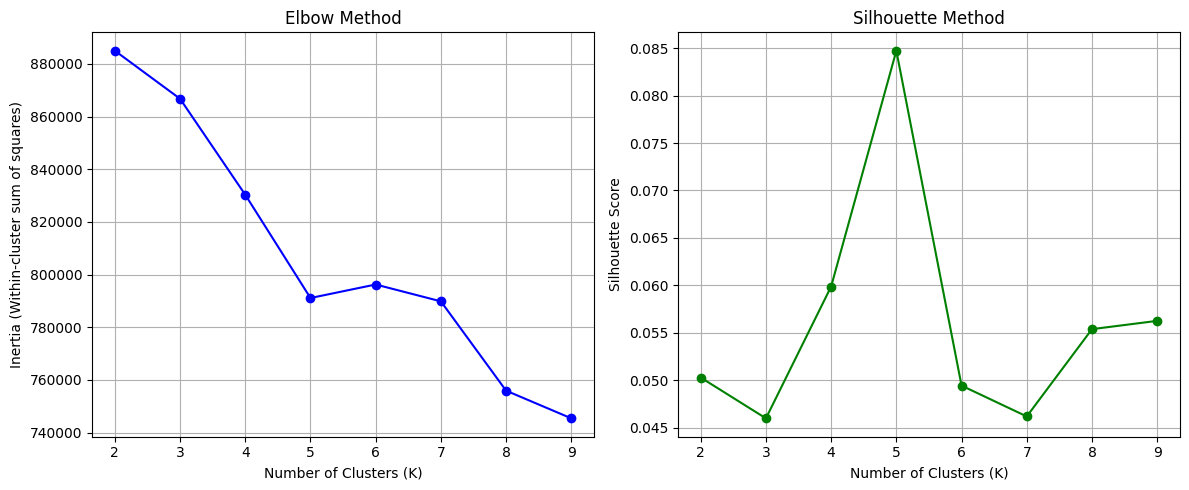

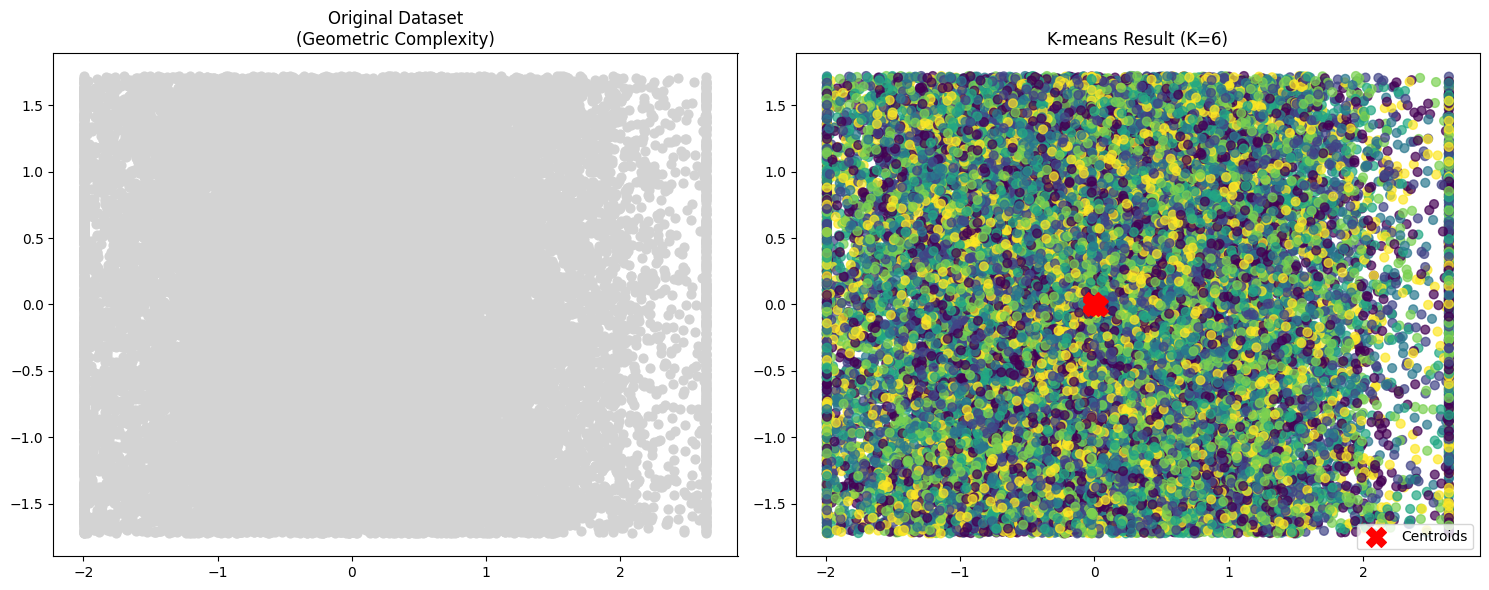

Final Cluster Assignments for each data point:
[3 4 4 ... 4 3 2]


In [48]:
import matplotlib.pyplot as plt
# Plot Elbow Curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.grid(True)

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'go-')
plt.title('Silhouette Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

# Visual cue for the "Elbow"
plt.show()

K=6
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)
centroids = kmeans.cluster_centers_

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left: Original Data Structure
ax1.scatter(df_scaled[:, 0], df_scaled[:, 1], c='lightgrey', s=40)
ax1.set_title("Original Dataset\n(Geometric Complexity)")

# Right: K-means 
ax2.scatter(df_scaled[:, 0], df_scaled[:, 1], c=clusters, cmap='viridis', s=40, alpha=0.7)
ax2.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
ax2.set_title(f"K-means Result (K={K})")
ax2.legend()

plt.tight_layout()
plt.show()

print("Final Cluster Assignments for each data point:")
print(kmeans.labels_)



Train Accuracy: 0.6691
Test Accuracy:  0.6353


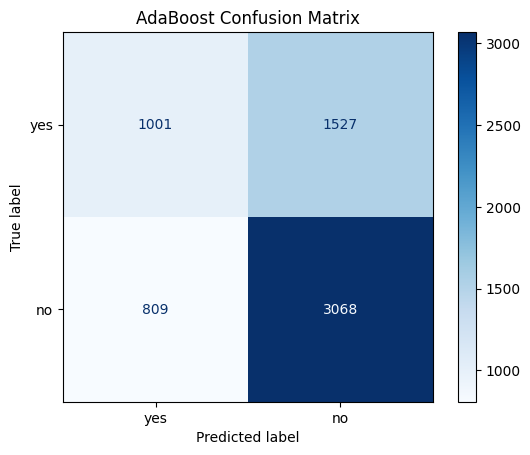

Decision Tree:
  Train Accuracy: 0.6305
  Test Accuracy:  0.6181


In [57]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Define AdaBoost with shallow trees
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=5),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

# Fit the model
adaboost.fit(X_train, y_train)

# Evaluate
print(f"Train Accuracy: {adaboost.score(X_train, y_train):.4f}")
print(f"Test Accuracy:  {adaboost.score(X_test, y_test):.4f}")

# Predictions
y_pred = adaboost.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['yes','no'])

disp.plot(cmap='Blues')
plt.title("AdaBoost Confusion Matrix")
plt.grid(False)
plt.show()

# Base Decision Tree (depth=1)
tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_clf.fit(X_train, y_train)
# Accuracy
print("Decision Tree:")
print(f"  Train Accuracy: {tree_clf.score(X_train, y_train):.4f}")
print(f"  Test Accuracy:  {tree_clf.score(X_test, y_test):.4f}")


In [58]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize Gradient Boosting
gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Fit model
gb_clf.fit(X_train, y_train)

# Evaluate
print(f"Train Accuracy: {gb_clf.score(X_train, y_train):.4f}")
print(f"Test Accuracy:  {gb_clf.score(X_test, y_test):.4f}")


Train Accuracy: 0.6597
Test Accuracy:  0.6459


In [62]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,
                            max_samples=100, n_jobs=-1, random_state=42, oob_score=True)
bag_clf.fit(X_train, y_train)

# Evaluate
print(f"Train Accuracy: {bag_clf.score(X_train, y_train):.4f}")
print(f"Test Accuracy:  {bag_clf.score(X_test, y_test):.4f}")
bag_clf.oob_score_

Train Accuracy: 0.6284
Test Accuracy:  0.6256


0.6241948705937463

In [8]:
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

svm_clf = SVC(C=0.2, gamma=0.6, random_state=42)
svm_clf.fit(X_train, y_train, sample_weight=sample_weights)
y_pred = svm_clf.predict(X_test)

print(f"Train Accuracy: {svm_clf.score(X_train, y_train):.4f}")
print(f"Test Accuracy:  {svm_clf.score(X_test, y_test):.4f}")

Train Accuracy: 0.6116
Test Accuracy:  0.6053


In [ ]:
from sklearn.ensemble import StackingClassifier

stacking_clf = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('svc', SVC(probability=True, random_state=42))
    ],
    final_estimator=RandomForestClassifier(random_state=43),
    cv=5  # number of cross-validation folds
)
stacking_clf.fit(X_train_scaled, y_train)
stacking_clf.score(X_test_scaled, y_test)

In [ ]:
#Insights
#models successfuly identify on time completion projects better than predicting delays
#features that are really critical for the project delays are identified, it is important to focus on safety issues, material delays and change requests to fasten project delivery

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create and train the Logistic Regression model
logistic_model = LogisticRegression()
logistic_model.fit(X_train, y_train)

# Predict on test data
y_pred = logistic_model.predict(X_test)

# Evaluate the model
print("\nLogistic Regression:")
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

from sklearn.metrics import log_loss

# Predict probabilities (not just labels)
y_pred_prob = logistic_model.predict_proba(X_test)
# print('log loss',y_pred_prob)
print(f"Log Loss: {log_loss(y_test, y_pred_prob)}")



Logistic Regression:
Accuracy: 0.6455893832943014
Confusion Matrix:
[[ 916 1612]
 [ 658 3219]]
Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.36      0.45      2528
           1       0.67      0.83      0.74      3877

    accuracy                           0.65      6405
   macro avg       0.62      0.60      0.59      6405
weighted avg       0.63      0.65      0.62      6405

Log Loss: 0.616467251614645


In [10]:
from sklearn.neural_network import MLPClassifier

# Create and train the model
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
mlp.fit(X_train_selected, y_train)

# Predict and evaluate
y_pred = mlp.predict(X_test_selected)

# Print evaluation metrics
print("Classification Report:\n")
print(classification_report(y_test, y_pred))


C:\Users\sramasu\Documents\Sankari\Code\18012026-20260201T073350Z-3-001\18012026\Setting up\gen-ai\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Classification Report:

              precision    recall  f1-score   support

           0       0.53      0.42      0.47      2528
           1       0.67      0.75      0.71      3877

    accuracy                           0.62      6405
   macro avg       0.60      0.59      0.59      6405
weighted avg       0.61      0.62      0.61      6405



 RBF SVM EVALUATION METRICS for  C  0.1  gamma  0.1
Accuracy:          0.6406
Precision:         0.6412
Recall:            0.9226
F1 Score:          0.7566
ROC-AUC Score:     0.6638



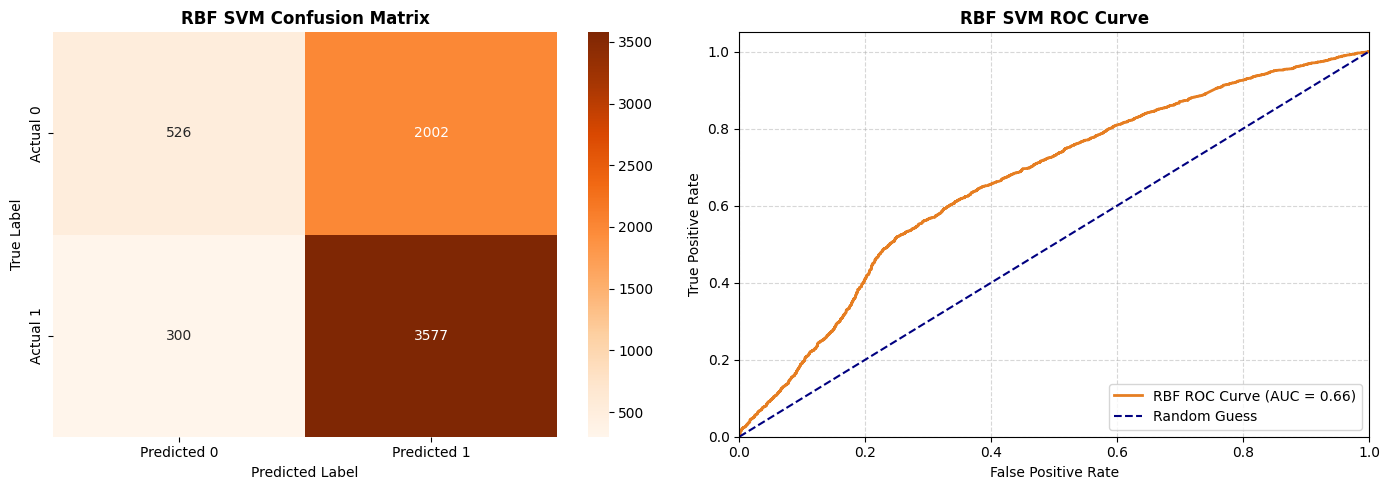

 RBF SVM EVALUATION METRICS for  C  1  gamma  0.1
Accuracy:          0.6440
Precision:         0.6503
Recall:            0.8912
F1 Score:          0.7519
ROC-AUC Score:     0.6652



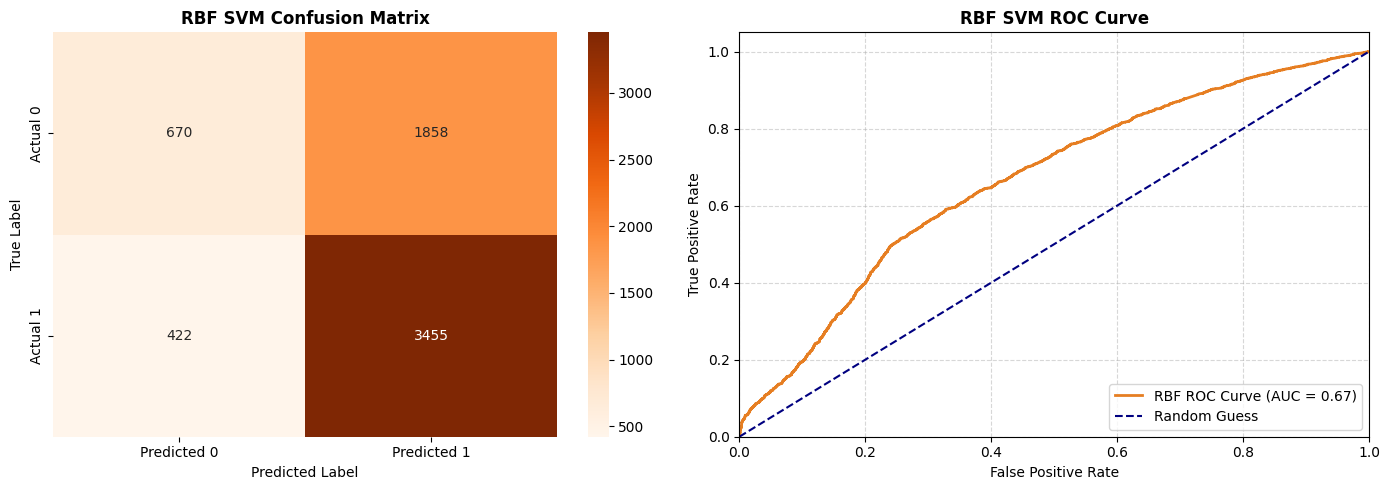

 RBF SVM EVALUATION METRICS for  C  0.1  gamma  5
Accuracy:          0.6056
Precision:         0.6056
Recall:            0.9992
F1 Score:          0.7541
ROC-AUC Score:     0.5666



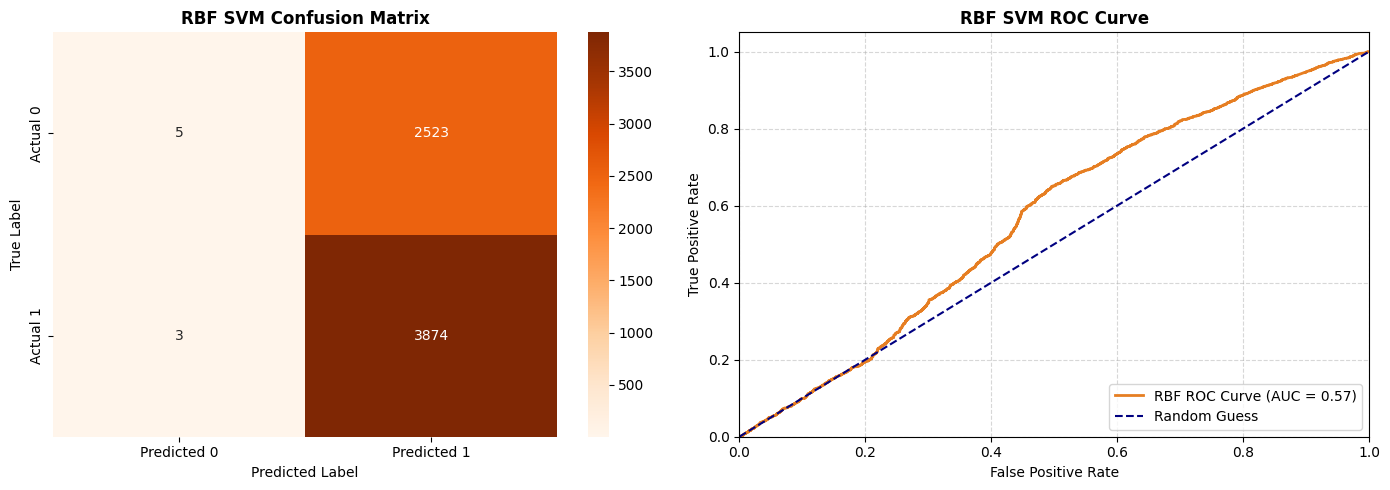

 RBF SVM EVALUATION METRICS for  C  1  gamma  5
Accuracy:          0.6025
Precision:         0.6350
Recall:            0.8076
F1 Score:          0.7109
ROC-AUC Score:     0.5507



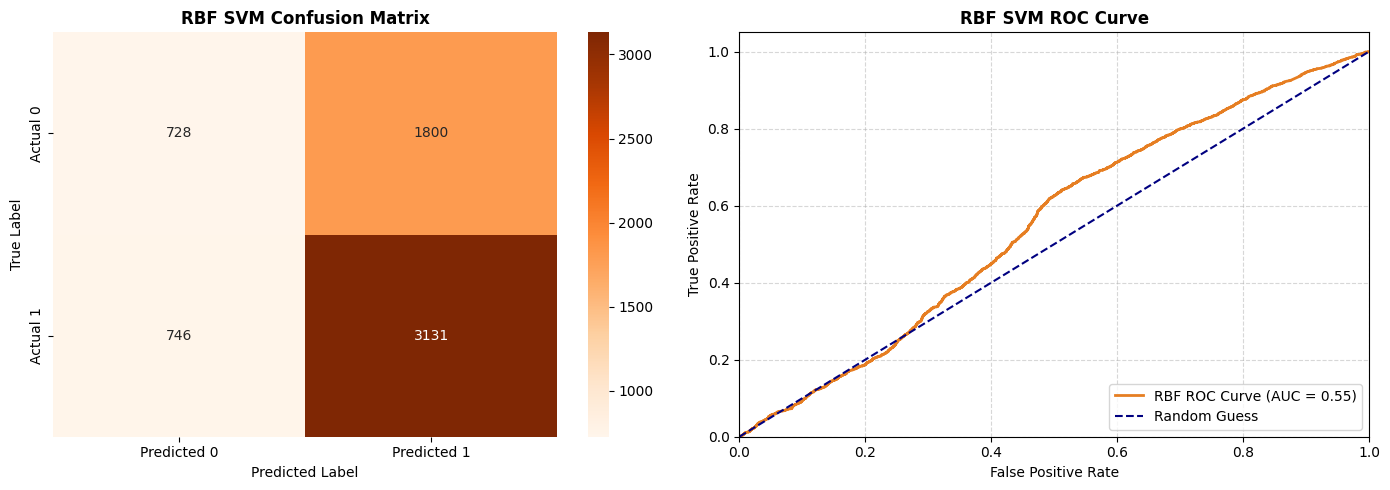

 RBF SVM EVALUATION METRICS for  C  10  gamma  0.1
Accuracy:          0.6464
Precision:         0.6549
Recall:            0.8788
F1 Score:          0.7505
ROC-AUC Score:     0.6613



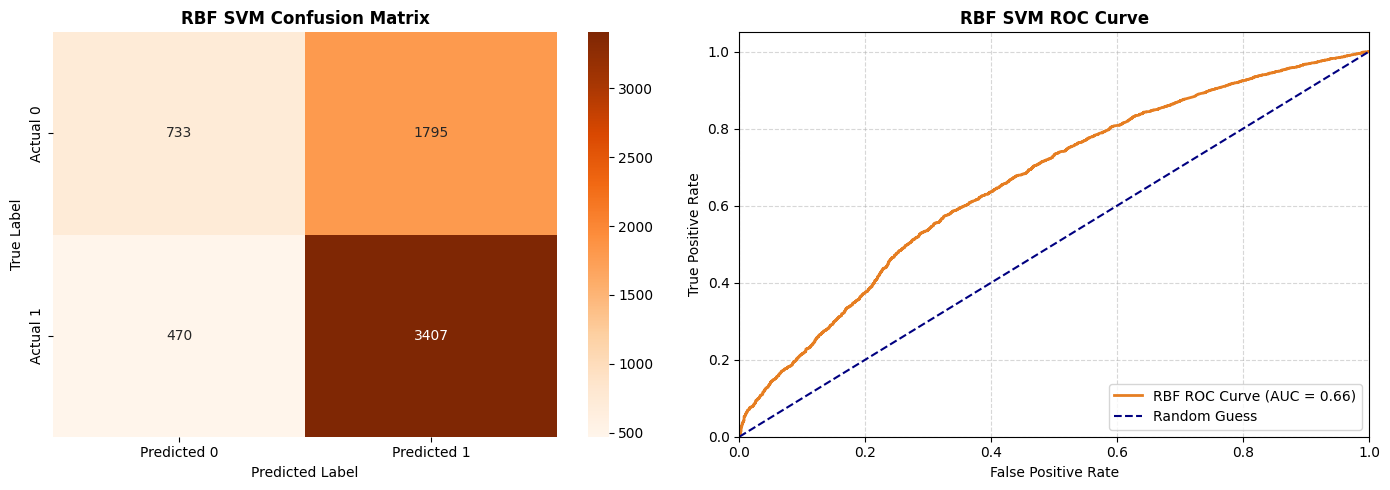

 RBF SVM EVALUATION METRICS for  C  10  gamma  5
Accuracy:          0.5835
Precision:         0.6357
Recall:            0.7305
F1 Score:          0.6798
ROC-AUC Score:     0.5301



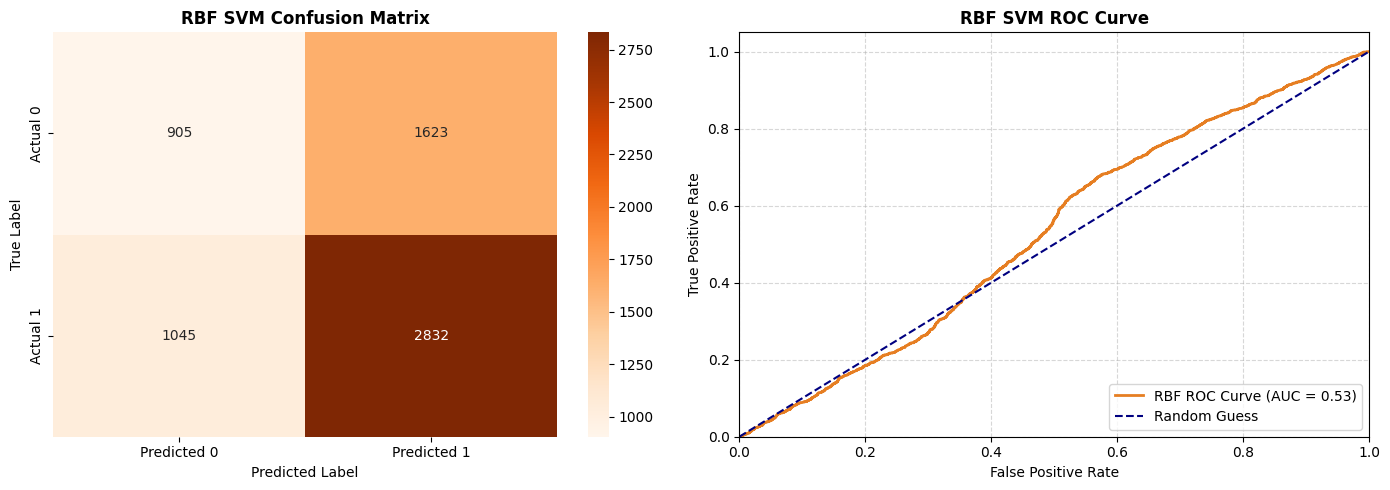

In [ ]:
from sklearn.svm import SVC
import seaborn as sns


import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    confusion_matrix, 
    roc_curve
)

# RBF Kernel SVM 
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)
    
# 1. Initialize the SVC with 'rbf' kernel
# 'scale' is the default for gamma, calculating 1 / (n_features * X.var())
def rbf_svc(X_train, y_train, X_test, y_test, c, g):
    rbf_svc = SVC(kernel='rbf', C=c, gamma=g, probability=True, random_state=42)
    rbf_svc.fit(X_train, y_train)
    
    # 2. Generate Predictions and Probabilities
    y_pred_rbf = rbf_svc.predict(X_test)
    y_probs_rbf = rbf_svc.predict_proba(X_test)[:, 1]
    
    # 3. Calculate Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred_rbf)
    precision = precision_score(y_test, y_pred_rbf)
    recall = recall_score(y_test, y_pred_rbf)
    f1 = f1_score(y_test, y_pred_rbf)
    roc_auc = roc_auc_score(y_test, y_probs_rbf)
    cm = confusion_matrix(y_test, y_pred_rbf)
    
    print("=========================================")
    print(" RBF SVM EVALUATION METRICS for  C " , c, " gamma ", g)
    print("=========================================")
    print(f"Accuracy:          {accuracy:.4f}")
    print(f"Precision:         {precision:.4f}")
    print(f"Recall:            {recall:.4f}")
    print(f"F1 Score:          {f1:.4f}")
    print(f"ROC-AUC Score:     {roc_auc:.4f}")
    print("=========================================\n")
    
    # 4. Plot Evaluation Visualizations
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
                xticklabels=['Predicted 0', 'Predicted 1'], 
                yticklabels=['Actual 0', 'Actual 1'])
    axes[0].set_title('RBF SVM Confusion Matrix', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_probs_rbf)
    axes[1].plot(fpr, tpr, color='#e67e22', lw=2, label=f'RBF ROC Curve (AUC = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guess')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('RBF SVM ROC Curve', fontsize=12, fontweight='bold')
    axes[1].legend(loc="lower right")
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    return rbf_svc

gamma1, gamma2 = 0.1, 5
C1, C2, C3, C4, C5 = 0.1, 1, 10, 100, 1000
hyperparams = (gamma1, C1), (gamma1, C2), (gamma2, C1), (gamma2, C2), (gamma1, C3), (gamma2, C3), (gamma1, C4), (gamma2, C4), (gamma1, C5), (gamma2, C5)

for gamma, C in hyperparams:
    model = rbf_svc(X_train_selected, y_train, X_test_selected, y_test, C, gamma)




 RBF SVM EVALUATION METRICS for  C  100  gamma  0.1
Accuracy:          0.6445
Precision:         0.6589
Recall:            0.8558
F1 Score:          0.7445
ROC-AUC Score:     0.6539



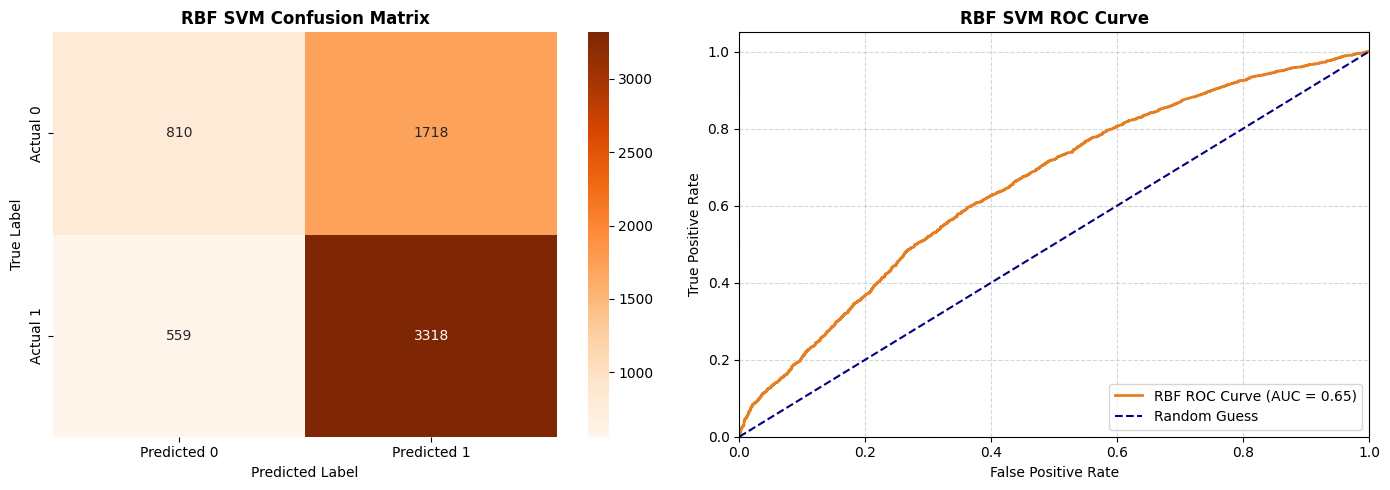

In [ ]:
from sklearn.svm import SVC
import seaborn as sns


import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    confusion_matrix, 
    roc_curve
)

# RBF Kernel SVM 
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)
    
# 1. Initialize the SVC with 'rbf' kernel
# 'scale' is the default for gamma, calculating 1 / (n_features * X.var())
def rbf_svc(X_train, y_train, X_test, y_test, c, g):
    rbf_svc = SVC(kernel='rbf', C=c, gamma=g, probability=True, random_state=42)
    rbf_svc.fit(X_train, y_train)
    
    # 2. Generate Predictions and Probabilities
    y_pred_rbf = rbf_svc.predict(X_test)
    y_probs_rbf = rbf_svc.predict_proba(X_test)[:, 1]
    
    # 3. Calculate Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred_rbf)
    precision = precision_score(y_test, y_pred_rbf)
    recall = recall_score(y_test, y_pred_rbf)
    f1 = f1_score(y_test, y_pred_rbf)
    roc_auc = roc_auc_score(y_test, y_probs_rbf)
    cm = confusion_matrix(y_test, y_pred_rbf)
    
    print("=========================================")
    print(" RBF SVM EVALUATION METRICS for  C " , c, " gamma ", g)
    print("=========================================")
    print(f"Accuracy:          {accuracy:.4f}")
    print(f"Precision:         {precision:.4f}")
    print(f"Recall:            {recall:.4f}")
    print(f"F1 Score:          {f1:.4f}")
    print(f"ROC-AUC Score:     {roc_auc:.4f}")
    print("=========================================\n")
    
    # 4. Plot Evaluation Visualizations
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
                xticklabels=['Predicted 0', 'Predicted 1'], 
                yticklabels=['Actual 0', 'Actual 1'])
    axes[0].set_title('RBF SVM Confusion Matrix', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_probs_rbf)
    axes[1].plot(fpr, tpr, color='#e67e22', lw=2, label=f'RBF ROC Curve (AUC = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guess')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('RBF SVM ROC Curve', fontsize=12, fontweight='bold')
    axes[1].legend(loc="lower right")
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    return rbf_svc

gamma1, gamma2 = 0.1, 5
C1, C2 =  100, 1000
hyperparams = (gamma1, C1), (gamma1, C2), (gamma2, C1), (gamma2, C2)

for gamma, C in hyperparams:
    model = rbf_svc(X_train_selected, y_train, X_test_selected, y_test, C, gamma)

#with different C and gamma C=10  gamma  0.1 performs better as per confusion matrix and F1 score



In [14]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression


base_estimators = [
    ('svc', SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced', C=0.1, gamma=0.1)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')),
    ('gb', GradientBoostingClassifier(random_state=42)) 
]

meta_estimator = LogisticRegression(random_state=42)


stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_estimator,
    cv=5,
    n_jobs=-1 
)

stacking_model.fit(X_train_selected, y_train)

y_pred = stacking_model.predict(X_test_selected)



In [ ]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
y_pred = stacking_model.predict(X_test_selected)
y_pred_proba = stacking_model.predict_proba(X_test_selected)[:, 1] # Probability of being delayed

print("========== MODEL PERFORMANCE EVALUATION ==========")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")
print("==================================================\n")

print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))